In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score, accuracy_score

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv'

In [3]:
!wget $data -O course_lead_scoring.csv 

--2026-01-11 20:05:08--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80876 (79K) [text/plain]
Saving to: ‘course_lead_scoring.csv’

course_lead_scoring 100%[===================>]  78.98K  --.-KB/s    in 0.002s  

2026-01-11 20:05:08 (31.5 MB/s) - ‘course_lead_scoring.csv’ saved [80876/80876]



In [4]:
df = pd.read_csv('course_lead_scoring.csv')

In [5]:
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [6]:
categorical_columns = list(df.dtypes[df.dtypes=='object'].index) #alexey, requires logic and understadning masks hehe


for c in categorical_columns:
    df[c] = df[c].fillna('NA')

In [7]:
numerical_columns = list(df.dtypes[df.dtypes!='object'].index) 
#assumed anything that is not object is a number, this might be a bad idea though.


for c in numerical_columns:
    df[c] = df[c].fillna(0.0)

In [8]:
numerical_columns

['number_of_courses_viewed',
 'annual_income',
 'interaction_count',
 'lead_score',
 'converted']

In [9]:
df[numerical_columns].isna().sum()

number_of_courses_viewed    0
annual_income               0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [10]:
df[categorical_columns].isna().sum()
# confirmed.

lead_source          0
industry             0
employment_status    0
location             0
dtype: int64

In [11]:
df.industry.mode()

0    retail
Name: industry, dtype: object

In [12]:
correlation_table = df[numerical_columns].corr()

In [13]:
df.interaction_count.corr(df.lead_score)

np.float64(0.009888182496913084)

In [14]:
df.number_of_courses_viewed.corr(df.lead_score)

np.float64(-0.004878998354681257)

In [15]:
df.number_of_courses_viewed.corr(df.interaction_count)

np.float64(-0.023565222882888117)

In [16]:
df.annual_income.corr(df.interaction_count)

np.float64(0.02703647240481436)

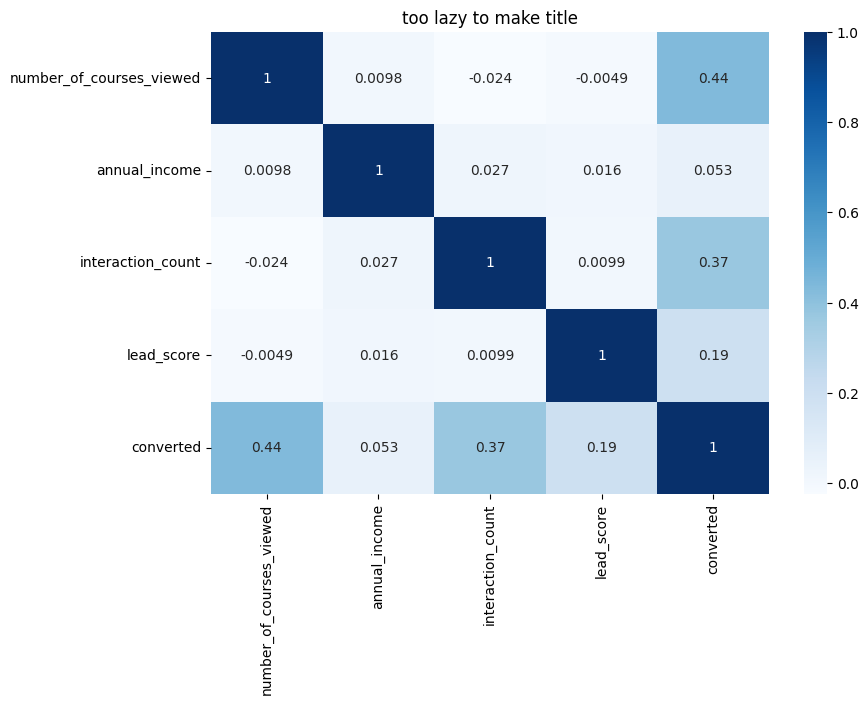

In [17]:
plt.figure(figsize=(9, 6))
sns.heatmap(
    correlation_table,
    annot=True,
    cmap="Blues"
)
plt.title('too lazy to make title')
plt.show()

In [18]:
df_full_train, df_test = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

In [19]:
df_train, df_val = train_test_split(
    df_full_train,
    test_size=0.25,
    random_state=42    
)

In [20]:
df_full_train.reset_index(drop=True)
df_train.reset_index(drop=True)
df_test.reset_index(drop=True)
df_val.reset_index(drop=True)

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,healthcare,3,52220.0,unemployed,europe,1,0.07,0
1,organic_search,technology,3,59656.0,unemployed,middle_east,4,0.65,1
2,events,manufacturing,0,57134.0,self_employed,north_america,4,0.13,0
3,events,other,0,0.0,NA,asia,0,0.03,0
4,referral,retail,1,54103.0,unemployed,south_america,3,0.16,0
...,...,...,...,...,...,...,...,...,...
288,social_media,healthcare,1,55222.0,self_employed,africa,1,0.25,0
289,paid_ads,NA,1,20326.0,employed,middle_east,3,0.81,1
290,organic_search,technology,1,74166.0,employed,south_america,2,0.01,0
291,organic_search,technology,2,39103.0,self_employed,africa,3,0.60,1


In [21]:
y_train = df_train['converted']
y_test = df_test['converted']
y_val = df_val['converted']

In [22]:
del df_train['converted']
del df_test['converted']
del df_val['converted']

In [23]:
from sklearn.metrics import mutual_info_score

In [24]:
categorical_cols=df_train.dtypes[df_train.dtypes=='object'].index.to_list()

In [25]:
categorical = df_train[categorical_cols]

In [34]:
categorical.shape[0]

876

In [32]:
categorical.shape[1]

4

In [33]:
categorical.head()

,lead_source,industry,employment_status,location
1077,paid_ads,retail,student,middle_east
463,organic_search,manufacturing,student,middle_east
842,paid_ads,technology,employed,north_america
835,NA,technology,employed,europe
837,organic_search,retail,student,australia


In [39]:
for i in range(categorical.shape[1]):
    print("y_train", "and", categorical.columns[i], ":", mutual_info_score(y_train, categorical.iloc[:,i]))

y_train and lead_source : 0.03539624379726594
y_train and industry : 0.011574521435657112
y_train and employment_status : 0.012937677269442782
y_train and location : 0.004464157884038034
